In [6]:
import matplotlib.pyplot as plt
import pandas as pd

hvi = pd.read_csv('../data/export_hvi_hdong_202208.xls',
                  encoding='utf-8-sig', dtype={'hdong_code': str})

plt.rcParams['font.family'] = 'AppleGothic'  # Mac
# plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows

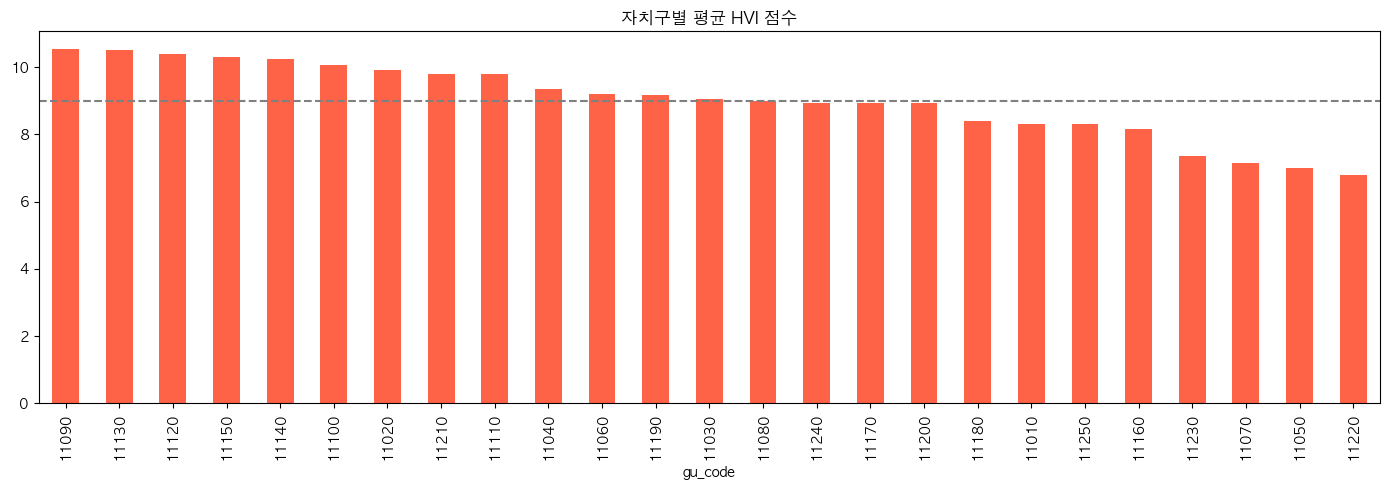

In [7]:
hvi['gu_code'] = hvi['hdong_code'].str[:5]
gu_avg = hvi.groupby('gu_code')['HVI_score'].mean().sort_values(ascending=False)

gu_avg.plot(kind='bar', figsize=(14,5), color='tomato')
plt.axhline(y=hvi['HVI_score'].mean(), color='gray', linestyle='--', label='서울 평균')
plt.title('자치구별 평균 HVI 점수')
plt.tight_layout()
plt.savefig('gu_hvi_bar.png', dpi=150)

KeyError: 'unit_density'

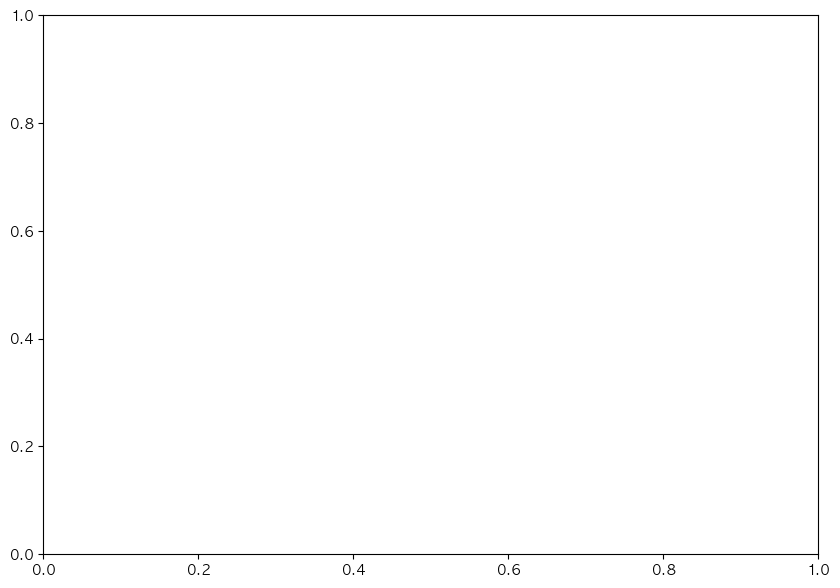

In [8]:
fig, ax = plt.subplots(figsize=(10,7))
sc = ax.scatter(
    hvi['old_ratio'],
    hvi['low_ratio_combined'],
    s=hvi['unit_density'] * 5000,
    c=hvi['HVI_score'],
    cmap='YlOrRd', alpha=0.6
)
plt.colorbar(sc, label='HVI 점수')
ax.set_xlabel('노후도 비율')
ax.set_ylabel('저가 주거지 비율')
ax.set_title('행정동별 HVI 구성 요소 분포')
plt.tight_layout()
plt.savefig('hvi_scatter.png', dpi=150)

In [ ]:
fig, ax = plt.subplots(figsize=(10,7))
sc = ax.scatter(
    hvi['old_ratio'],
    hvi['low_ratio_combined'],
    s=hvi['unit_density'] * 5000,
    c=hvi['HVI_score'],
    cmap='YlOrRd', alpha=0.6
)
plt.colorbar(sc, label='HVI 점수')
ax.set_xlabel('노후도 비율')
ax.set_ylabel('저가 주거지 비율')
ax.set_title('행정동별 HVI 구성 요소 분포')
plt.tight_layout()
plt.savefig('hvi_scatter.png', dpi=150)

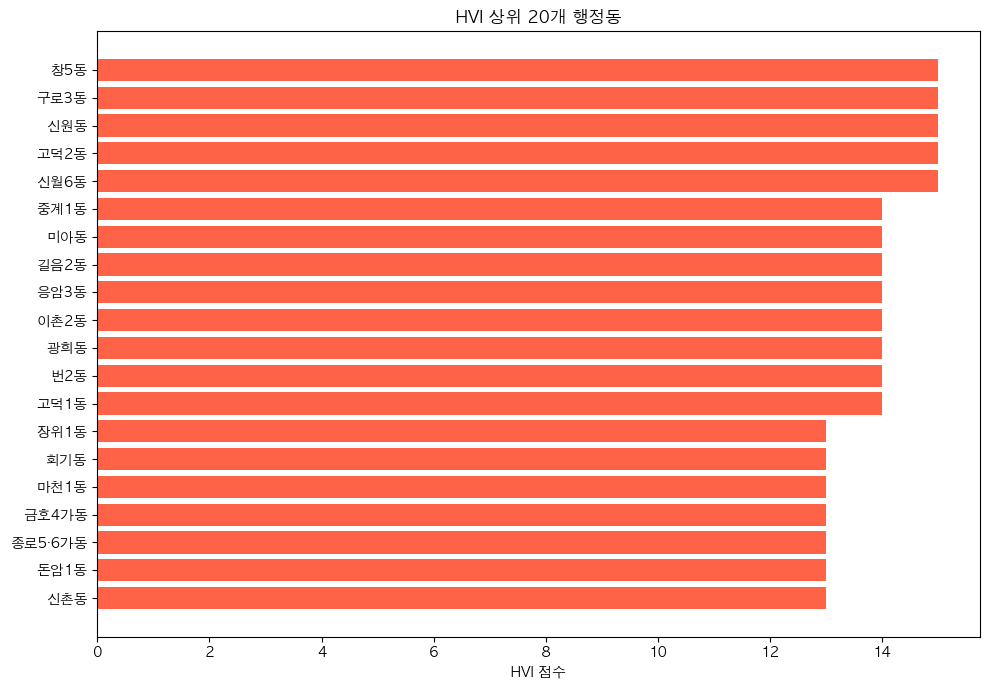

In [9]:
top20 = hvi.sort_values('HVI_rank').head(20)

fig, ax = plt.subplots(figsize=(10,7))
ax.barh(top20['hdong_name'], top20['HVI_score'], color='tomato')
ax.set_xlabel('HVI 점수')
ax.set_title('HVI 상위 20개 행정동')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('hvi_top20.png', dpi=150)